<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Sionna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.1/562.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.0 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found e

In [3]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

TensorFlow: 2.20.0
Sionna: 2.0.1


In [4]:
# Import Sionna Modules
from sionna.phy.channel import AWGN
from sionna.phy.mapping import Mapper
from sionna.phy.mapping import Demapper

print("Modules Imported Successfully")

Modules Imported Successfully


In [6]:
# Simulation Parameters
NUM_BITS = 10000

SNR_dB = np.arange(0,21,2)

ber = []

# Generate Random Bits
bits = tf.random.uniform(
    [NUM_BITS],
    maxval=2,
    dtype=tf.int32
)

print(bits[:20])

tf.Tensor([1 0 0 0 0 0 1 1 0 0 1 1 1 0 0 1 1 0 1 1], shape=(20,), dtype=int32)


In [7]:
# BPSK Mapping
symbols = 2*tf.cast(bits,tf.float32)-1

print(symbols[:20])

tf.Tensor(
[ 1. -1. -1. -1. -1. -1.  1.  1. -1. -1.  1.  1.  1. -1. -1.  1.  1. -1.
  1.  1.], shape=(20,), dtype=float32)


In [18]:
print("SNR_dB:", SNR_dB)
print("Length of SNR_dB:", len(SNR_dB))

print("BER:", ber)
print("Length of BER:", len(ber))
print(ber)

SNR_dB: [ 0  2  4  6  8 10 12 14 16 18 20]
Length of SNR_dB: 11
BER: [np.float64(0.0801), np.float64(0.0379), np.float64(0.0121), np.float64(0.0022), np.float64(0.0001), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0783), np.float64(0.0392), np.float64(0.0092), np.float64(0.0016), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0801), np.float64(0.0392), np.float64(0.0131), np.float64(0.0021), np.float64(0.0001), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0785), np.float64(0.0338), np.float64(0.0127), np.float64(0.0025), np.float64(0.0001), np.float64(0.0001), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Length of BER: 44
[np.float64(0.0801), np.float64(0.0379), np.float64(0.0121), np.float64(0.0022), np.float64(0.0001), np.

In [21]:
# AWGN Channel
ber = []
for snr in SNR_dB:

    sigma = np.sqrt(1/(2*10**(snr/10)))

    noise = sigma*tf.random.normal(symbols.shape)

    rx = symbols+noise

    detected=tf.cast(rx>0,tf.int32)

    errors=tf.reduce_sum(
        tf.cast(
            detected!=bits,
            tf.int32
        )
    )

    ber.append(errors.numpy()/NUM_BITS)

In [23]:
print(ber)

[np.float64(0.0806), np.float64(0.0379), np.float64(0.012), np.float64(0.0023), np.float64(0.0003), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [22]:
len(ber)

11

In [24]:
SNR_dB = np.arange(0,21,2)

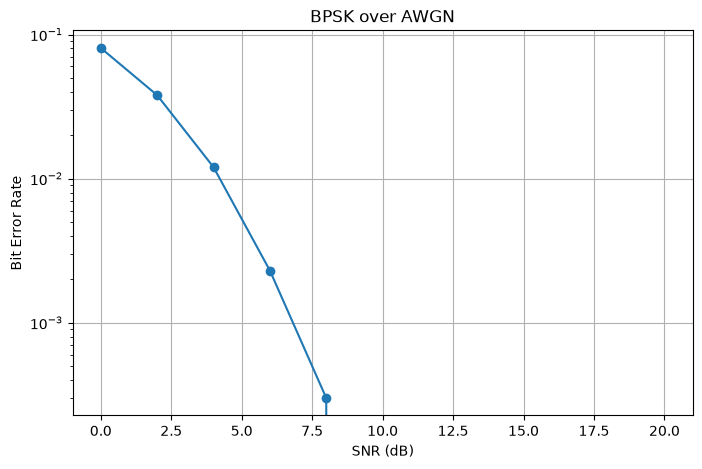

In [25]:
# BER Curve
plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    ber,
    marker='o'
)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Bit Error Rate")

plt.title("BPSK over AWGN")

plt.savefig(
    "figures_step9_ber_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
import sionna
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Sionna Version:", sionna.__version__)

TensorFlow Version: 2.20.0
Sionna Version: 2.0.1


In [27]:
import sionna

print(dir(sionna))

['ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'importlib', 'phy', 'pkgutil']


In [28]:
print("Sionna Version:", sionna.__version__)

Sionna Version: 2.0.1


In [29]:
import pkgutil
import sionna

print("Available Sionna Modules\n")

for module in pkgutil.iter_modules(sionna.__path__):
    print(module.name)

Available Sionna Modules

phy
rt
sys


In [30]:
import sionna.phy

print(dir(sionna.phy))

['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']
